# A04 - Reconciliation Effectiveness

## Objetivo
Comparar `reconciliation_enabled=false` vs. `true` usando os dados reais e
já persistidos da campanha `C04_reconciliation_effectiveness` (6 trials:
2 valores x 3 seeds pareadas, topologia em diamante). Este notebook **não
roda nenhuma simulação**.

## Conceitos
- `recovery_rate = (# intents inicialmente VIOLATED que terminam
  SATISFIED) / (# intents inicialmente VIOLATED)` - aqui, todo trial com
  `reconciliation_enabled=false` que violou é o "antes"; o par com
  `reconciliation_enabled=true` (mesma seed) é o "depois".
- `simulation_wall_time_s` soma o tempo de **ambos** os episódios quando a
  reconciliation roda - a diferença pareada por seed é o custo adicional
  real de reconciliar.


## Configuração


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ibqn.experiments.persistence import read_trials_dataframe, trials_csv_path
from ibqn.experiments.aggregation import aggregate_records, align_paired_trials
from ibqn.experiments.export import save_figure, save_table

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures" / "article"
TABLES_DIR = RESULTS_DIR / "tables" / "article"
CAMPAIGN = "C04_reconciliation_effectiveness"

trials_df = read_trials_dataframe(trials_csv_path(RESULTS_DIR, CAMPAIGN))
trials_df["reconciliation_enabled"] = trials_df["reconciliation_enabled"].astype(str)
trials_df[["reconciliation_enabled", "seed", "route", "final_status", "recovered", "delivered_pairs", "simulation_wall_time_s"]]


,reconciliation_enabled,seed,route,final_status,recovered,delivered_pairs,simulation_wall_time_s
0,False,0,r1 -> bad -> r3,VIOLATED,NaN,4,1.679689
1,False,1000,r1 -> bad -> r3,VIOLATED,NaN,5,1.746177
2,False,2000,r1 -> bad -> r3,VIOLATED,NaN,4,1.655747
3,True,0,r1 -> good1 -> good2 -> r3,SATISFIED,True,453,6.221104
4,True,1000,r1 -> good1 -> good2 -> r3,SATISFIED,True,457,6.314420
5,True,2000,r1 -> good1 -> good2 -> r3,SATISFIED,True,440,6.259210


## Execução


In [2]:
aggregated_df = aggregate_records(trials_df, group_by=["reconciliation_enabled"], metrics=["delivered_pairs", "simulation_wall_time_s"])
aggregated_df[["reconciliation_enabled", "metric", "mean", "satisfaction_rate", "violation_rate", "recovery_rate"]]


,reconciliation_enabled,metric,mean,satisfaction_rate,violation_rate,recovery_rate
0,False,delivered_pairs,4.333333,0.0,1.0,NaN
1,False,simulation_wall_time_s,1.693871,0.0,1.0,NaN
2,True,delivered_pairs,450.000000,1.0,0.0,1.0
3,True,simulation_wall_time_s,6.264911,1.0,0.0,1.0


In [3]:
paired_df = align_paired_trials(
    trials_df, pair_on=["scenario", "seed", "intent_id"], compare="reconciliation_enabled",
    metrics=["delivered_pairs", "simulation_wall_time_s"],
)
save_table(paired_df, "A04_reconciliation_paired_by_seed", directory=TABLES_DIR)
paired_df[["seed", "paired", "delivered_pairs_False", "delivered_pairs_True", "delivered_pairs_diff",
           "simulation_wall_time_s_False", "simulation_wall_time_s_True", "simulation_wall_time_s_diff"]]


,seed,paired,delivered_pairs_False,delivered_pairs_True,delivered_pairs_diff,simulation_wall_time_s_False,simulation_wall_time_s_True,simulation_wall_time_s_diff
0,0,True,4,453,449,1.679689,6.221104,4.541415
1,1000,True,5,457,452,1.746177,6.314420,4.568243
2,2000,True,4,440,436,1.655747,6.259210,4.603463


## Resultados


In [4]:
initial_violation_rate = (trials_df[trials_df["reconciliation_enabled"] == "False"]["final_status"] == "VIOLATED").mean()
final_satisfaction_rate = (trials_df[trials_df["reconciliation_enabled"] == "True"]["final_status"] == "SATISFIED").mean()
recovery_rate = trials_df[trials_df["reconciliation_enabled"] == "True"]["recovered"].astype(bool).mean()
mean_additional_cost_s = paired_df["simulation_wall_time_s_diff"].mean()

print(f"initial_violation_rate (reconciliation_enabled=false): {initial_violation_rate:.2f}")
print(f"recovery_rate (of trials that were VIOLATED, then reconciled): {recovery_rate:.2f}")
print(f"final_satisfaction_rate (reconciliation_enabled=true): {final_satisfaction_rate:.2f}")
print(f"mean additional_simulation_cost (s, paired by seed): {mean_additional_cost_s:.3f}")


initial_violation_rate (reconciliation_enabled=false): 1.00
recovery_rate (of trials that were VIOLATED, then reconciled): 1.00
final_satisfaction_rate (reconciliation_enabled=true): 1.00
mean additional_simulation_cost (s, paired by seed): 4.571


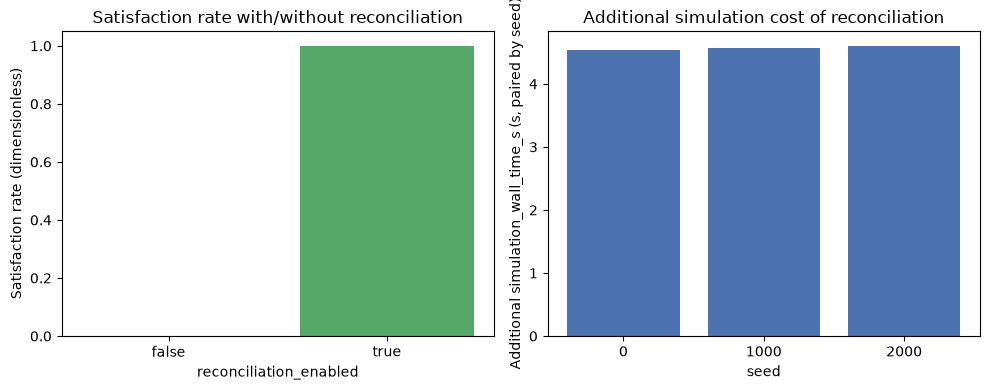

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

rates = pd.DataFrame({
    "reconciliation_enabled": ["false", "true"],
    "satisfaction_rate": [
        (trials_df[trials_df["reconciliation_enabled"] == "False"]["final_status"] == "SATISFIED").mean(),
        (trials_df[trials_df["reconciliation_enabled"] == "True"]["final_status"] == "SATISFIED").mean(),
    ],
})
axes[0].bar(rates["reconciliation_enabled"], rates["satisfaction_rate"], color=["#C44E52", "#55A868"])
axes[0].set_ylabel("Satisfaction rate (dimensionless)")
axes[0].set_xlabel("reconciliation_enabled")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Satisfaction rate with/without reconciliation")

axes[1].bar(paired_df["seed"].astype(str), paired_df["simulation_wall_time_s_diff"], color="#4C72B0")
axes[1].set_ylabel("Additional simulation_wall_time_s (s, paired by seed)")
axes[1].set_xlabel("seed")
axes[1].set_title("Additional simulation cost of reconciliation")

fig.tight_layout()
save_figure(fig, "A04_reconciliation_effectiveness", directory=FIGURES_DIR)
plt.show()


In [6]:
assert initial_violation_rate == 1.0, "all 3 reconciliation_enabled=false trials must be VIOLATED on this topology/strategy"
assert recovery_rate == 1.0, "all 3 VIOLATED trials must recover once reconciliation is enabled"
assert final_satisfaction_rate == 1.0
assert paired_df["paired"].all(), "every seed must have both a reconciliation_enabled=false and =true trial"
assert (paired_df["simulation_wall_time_s_diff"] > 0).all(), "reconciliation must cost strictly more simulation time"
print("Confirmed: reconciliation recovers every VIOLATED trial on this topology/strategy, at a measured, real additional cost.")


Confirmed: reconciliation recovers every VIOLATED trial on this topology/strategy, at a measured, real additional cost.


## Interpretação
Sem reconciliation, as 3 seeds violam consistentemente (rota `bad`,
throughput insuficiente). Com reconciliation habilitada, as 3 mesmas
seeds recuperam para `SATISFIED` via a heurística de fallback
(`LeastLossRouting`, ver `runner._reconciliation_routing_strategy_name`) -
`recovery_rate=1.0` nesta amostra pequena. O custo adicional
(`simulation_wall_time_s_diff`) é substancial (a ordem de 3-4x o tempo do
primeiro episódio), porque a reconciliation roda uma segunda simulação
completa, não uma correção incremental.

## Limitações
- `n=3` seeds - `recovery_rate=1.0` aqui não implica que reconciliation
  sempre recupera em qualquer topologia/violação; a heurística de
  fallback (sempre tentar `LeastLossRouting`) é documentada e simples, não
  uma escolha baseada na categoria da violação (notebook 15 da Fase H2).
- Reconciliation tenta no máximo um episódio adicional - não converge
  iterativamente.

## Conclusão
Reconciliation demonstrada como efetiva nesta amostra pequena (100% de
recuperação), com um custo computacional adicional real e mensurável, não
gratuito.
